In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from torch.utils.data import DataLoader

In [2]:
# reload modules
from importlib import reload

from utils.utils import find_subfolders
from utils.custom_data_loader import load_data

from utils.const import *

In [3]:
import os
import time



time = time.strftime("%Y%m%d%H%M%S", time.localtime())
save_path = r".\outputs" + "\\" + time

# create the directory
try:
    os.makedirs(save_path)
except FileExistsError:
    pass

# choose the device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [4]:
root_directory = r"/Users/zeeshawnh/College/GuoResearch/Transformer/data/physionet.org/files/challenge-2021/1.0.3/training"
dataset_paths = find_subfolders(root_directory)[0:1]
print(dataset_paths)

overlap = 1
lead_num = 1
cycle_num = 2

df_all, period_list = load_data(dataset_paths, lead_num=lead_num, max_circle=None,
                        cycle_num=cycle_num, overlap=overlap)  # abnormal or single_abnormal
# print("Data loaded. Datasets loaded: ", loaded_paths_abnormal)
print(f"Number of cycles: {len(df_all)}")
print(df_all.head())

['/Users/zeeshawnh/College/GuoResearch/Transformer/data/physionet.org/files/challenge-2021/1.0.3/training/ningbo']
Number of records: 16905
Number of cycles: 180627
   diagnosis  lead_point_1  lead_point_2  lead_point_3  lead_point_4  \
0          1    489.291929    379.655570    317.030375    199.583311   
1          1    547.392657    437.024567    265.922540    141.760389   
2          1    484.515475    457.125250    307.673652    207.025858   
3          1    605.671097    514.210476    411.820906    275.221931   
4          1    468.801768    433.948417    316.163597    210.350122   

   lead_point_5  lead_point_6  lead_point_7  lead_point_8  lead_point_9  ...  \
0    109.895788    -15.519290    -29.074766    -41.901487    -34.657169  ...   
1    124.628337     67.162338     32.779171     -2.024886      1.708591  ...   
2    102.278719     11.732221     -6.441590    -31.976693    -68.912492  ...   
3    124.027387     39.355392     46.045898     53.142635     29.494930  ...   
4 

In [5]:
import pandas as pd
from itertools import chain
import torch
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

# Get all unique diagnosis codes
all_codes = set(df_all['diagnosis'])

print(df_all['diagnosis'])

# Map diagnosis codes to integer labels
code_to_label = {code: idx for idx, code in enumerate(sorted(all_codes))}

print(code_to_label)

# Assign labels to the data
df_all['label'] = df_all['diagnosis'].apply(lambda x: code_to_label[x])

0         1
1         1
2         1
3         1
4         1
         ..
180622    1
180623    1
180624    1
180625    1
180626    1
Name: diagnosis, Length: 180627, dtype: int64
{1: 0, 2: 1, 3: 2, 5: 3}


In [6]:
# Separate cycles, durations, and labels
# Assuming cycle columns are named as 'lead_point_1', 'lead_point_2', ..., and duration columns are 'cycle_duration_1', 'cycle_duration_2', etc.
cycle_columns = [col for col in df_all.columns if col.startswith('lead_point_')]
duration_columns = [col for col in df_all.columns if col.startswith('cycle_duration_')]

# Combine cycle data and duration as input features
X_cycles = df_all[cycle_columns].values  # Cycle features
X_durations = df_all[duration_columns].values  # Duration features

# Combine cycle and duration into a single feature array
X = np.hstack([X_cycles, X_durations])
y = df_all['label'].values

# Split data into training and test sets (stratify to preserve label distribution)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=23, stratify=y
)

print("Sample of X_train data:\n", X_train[:2])  # Print first two samples for verification

Sample of X_train data:
 [[5.94218170e+02 6.81951674e+02 4.92837081e+02 ... 3.70766266e+02
  8.18000000e-01 8.08000000e-01]
 [3.66566269e+02 4.22801382e+02 3.95912344e+02 ... 1.48852281e+02
  6.26000000e-01 5.68000000e-01]]


In [7]:
# Get the number of cycle points and duration columns
num_cycle_points = len(cycle_columns)
num_duration_columns = len(duration_columns)

# Scale the cycle data and duration separately
scaler_cycles = MinMaxScaler()
scaler_durations = MinMaxScaler()

X_train_cycles_scaled = scaler_cycles.fit_transform(X_train[:, :num_cycle_points])  # Scale cycle data
X_train_durations_scaled = scaler_durations.fit_transform(X_train[:, num_cycle_points:])  # Scale duration data

X_test_cycles_scaled = scaler_cycles.transform(X_test[:, :num_cycle_points])
X_test_durations_scaled = scaler_durations.transform(X_test[:, num_cycle_points:])

# Combine scaled cycle and duration features
X_train_scaled = np.hstack([X_train_cycles_scaled, X_train_durations_scaled])
X_test_scaled = np.hstack([X_test_cycles_scaled, X_test_durations_scaled])

# Further split training data into training and validation sets
X_train_scaled, X_val_scaled, y_train, y_val = train_test_split(
    X_train_scaled, y_train, test_size=0.2, random_state=23, stratify=y_train
)

# Convert to PyTorch tensors
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)

X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.long)

X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

# Optionally, expand dimensions if needed (e.g., for CNN input)
X_train_tensor = X_train_tensor.unsqueeze(1)  # Shape: (batch_size, 1, num_features)
X_val_tensor = X_val_tensor.unsqueeze(1)
X_test_tensor = X_test_tensor.unsqueeze(1)

# Create datasets
train_dataset = torch.utils.data.TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = torch.utils.data.TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = torch.utils.data.TensorDataset(X_test_tensor, y_test_tensor)

# Create DataLoaders
train_batch_size = 64
train_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size=train_batch_size, shuffle=True
)
val_loader = torch.utils.data.DataLoader(
    val_dataset, batch_size=train_batch_size, shuffle=False
)
test_loader = torch.utils.data.DataLoader(
    test_dataset, batch_size=train_batch_size, shuffle=False
)

Training data shape: (144501, 514)
Validation data shape: (28901, 514)
Test data shape: (36126, 514)
Training labels distribution:
Label 0: 40640 samples
Label 1: 62343 samples
Label 2: 11172 samples
Label 3: 1445 samples

Validation labels distribution:
Label 0: 10160 samples
Label 1: 15587 samples
Label 2: 2793 samples
Label 3: 361 samples

Test labels distribution:
Label 0: 12700 samples
Label 1: 19483 samples
Label 2: 3492 samples
Label 3: 451 samples

Plotting first 5 ECG signals from the training set:


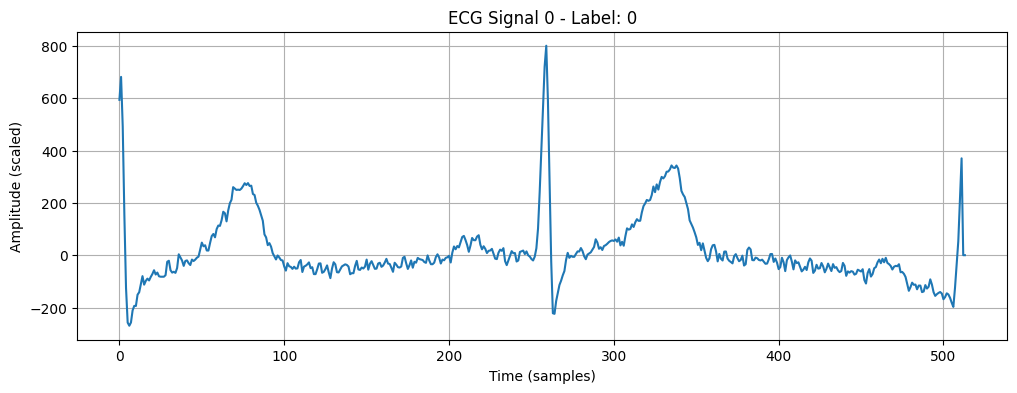

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# Print shapes of the datasets
print("Training data shape:", X_train.shape)
print("Validation data shape:", X_val_scaled.shape)
print("Test data shape:", X_test.shape)

# Print label distributions
unique, counts = np.unique(y_train, return_counts=True)
print("Training labels distribution:")
for label, count in zip(unique, counts):
    print(f"Label {label}: {count} samples")

unique, counts = np.unique(y_val, return_counts=True)
print("\nValidation labels distribution:")
for label, count in zip(unique, counts):
    print(f"Label {label}: {count} samples")

unique, counts = np.unique(y_test, return_counts=True)
print("\nTest labels distribution:")
for label, count in zip(unique, counts):
    print(f"Label {label}: {count} samples")

# Function to plot an ECG signal
def plot_ecg(signal, label, idx):
    
    plt.figure(figsize=(12, 4))
    plt.plot(signal)
    plt.title(f"ECG Signal {idx} - Label: {label}")
    plt.xlabel("Time (samples)")
    plt.ylabel("Amplitude (scaled)")
    plt.grid(True)
    plt.show()

# Plot first 5 samples from the training data
print("\nPlotting first 5 ECG signals from the training set:")
for i in range(1):
    signal = X_train[i]
    label = y_train[i]
    plot_ecg(signal, label, i)

# # Plot first 5 samples from the test data
# print("Plotting first 5 ECG signals from the test set:")
# for i in range(5):
#     signal = X_test[i]
#     label = y_test[i]
#     plot_ecg(signal, label, i)


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class MultiScaleConvEncoder(nn.Module):
    """
    Modality-specific encoder using multi-scale 1D convolutions to capture 
    features across different temporal granularities [6-8].
    """
    def __init__(self, input_channels=1, output_channels=64):
        super().__init__()
        # Kernel sizes used in the paper: {1, 3, 5, 7, 9, 11} [8]
        self.kernel_sizes = [2, 3, 9-12]
        self.convs = nn.ModuleList([
            nn.Conv1d(input_channels, output_channels // len(self.kernel_sizes), 
                      kernel_size=k, padding=k//2) 
            for k in self.kernel_sizes
        ])
        # Note: If output_channels is not divisible by 6, adjustments are made.

    def forward(self, x):
        # x shape: (B, 1, L) -> (Batch, Channels, Length)
        feat_list = [conv(x) for conv in self.convs]
        # Concatenate along the feature (channel) dimension [8]
        return torch.cat(feat_list, dim=1).permute(0, 2, 1) # (B, L, C)

class CustomizedTransformerModule(nn.Module):
    """
    Transformer module with task-specific attention masks and gated activation [13-15].
    """
    def __init__(self, embed_dim):
        super().__init__()
        self.embed_dim = embed_dim
        self.mha = nn.MultiheadAttention(embed_dim, num_heads=8, batch_first=True)
        self.f1 = nn.Linear(embed_dim, 2 * embed_dim) # For expansion before gating [15]
        self.f2 = nn.Linear(embed_dim, 2 * embed_dim) # For residual/skip split [16]

    def forward(self, h, diff_embedding, time_embedding, mask=None):
        # 1. Add diffusion embedding [14]
        h = h + diff_embedding 
        
        # 2. Multi-head self-attention with task-specific mask [14, 17]
        # The mask M blocks irrelevant information flow (e.g., target-to-condition) [17].
        attn_output, _ = self.mha(h, h, h, attn_mask=mask)
        
        # 3. Expansion and adding time embedding [15]
        h_prime = self.f1(attn_output) + time_embedding # (B, kL, 2C)
        
        # 4. Gated Activation Unit [15, 16]
        h1, h2 = torch.chunk(h_prime, 2, dim=-1)
        h_gated = torch.tanh(h1) * torch.sigmoid(h2) # (B, kL, C)
        
        # 5. Residual and Skip Connections [16, 18]
        h_out = self.f2(h_gated)
        res_part, skip_part = torch.chunk(h_out, 2, dim=-1)
        
        return h + res_part, skip_part

class ModalitySpecificDecoder(nn.Module):
    """
    Decoders implemented as two-layer MLPs with ReLU activation [19].
    """
    def __init__(self, input_dim=64):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(input_dim, input_dim),
            nn.ReLU(),
            nn.Linear(input_dim, 1)
        )

    def forward(self, x):
        return self.mlp(x) # (B, L, 1)

class UniCardio(nn.Module):
    def __init__(self, signal_length, embed_dim=64, num_modules=5):
        super().__init__()
        self.L = signal_length
        self.k = 4 # PPG, ECG, BP, and Auxiliary Modality (AM) [13]
        
        # Modality-specific Encoders [8]
        self.encoders = nn.ModuleList([MultiScaleConvEncoder(output_channels=embed_dim) for _ in range(self.k)])
        
        # Transformer Modules [13, 20]
        self.transformer_modules = nn.ModuleList([
            CustomizedTransformerModule(embed_dim) for _ in range(num_modules)
        ])
        
        # Modality-specific Decoders [19]
        self.decoders = nn.ModuleList([ModalitySpecificDecoder(input_dim=embed_dim) for _ in range(self.k - 1)])
        self.f3 = nn.Linear(embed_dim, embed_dim) # Final projection for skip summation [18]

    def forward(self, signals, diff_step_emb, time_emb, task_mask=None):
        # 1. Encoding phase [8]
        encoded_feats = [self.encoders[i](signals[i].transpose(1, 2)) for i in range(self.k)]
        # Concatenate along temporal dimension: (B, k*L, C) [8, 13]
        hs = torch.cat(encoded_feats, dim=1) 
        
        # 2. Transformer processing with residual and skip connections [13, 18]
        h = hs
        skip_total = 0
        for module in self.transformer_modules:
            h, skip = module(h, diff_step_emb, time_emb, mask=task_mask)
            skip_total += skip
            
        # 3. Final skip accumulation [18]
        hs_prime = self.f3(skip_total)
        
        # 4. Decoding phase [18, 19]
        # Split concatenated features back into modality-specific components
        split_feats = torch.split(hs_prime, self.L, dim=1)
        
        outputs = []
        for i in range(self.k - 1):
            outputs.append(self.decoders[i](split_feats[i]))
            
        return outputs

# KID-PPG Experimentation

In [ ]:
import importlib
import KID_PPG.helper_code
from scipy.io import loadmat
importlib.reload(KID_PPG.helper_code)

WFDBpath = "/Users/zeeshawnh/College/GuoResearch/data/physionet.org/files/senssmarttech/1.0.0/WFDB"
ecg_headers, ecg_recordings = KID_PPG.helper_code.find_ecg_files(WFDBpath)

# ecg_recording1 = pd.read_csv(ecg_recordings[0])

ecg1 = pd.read_csv("/Users/zeeshawnh/College/GuoResearch/data/physionet.org/files/senssmarttech/1.0.0/CSV/1_10-09-54_ecg.csv")
print(ecg1)

             t  lead_I  lead_II     v3     v4
0          0.1   19056   -37739 -28345 -36502
1          2.1   18067   -38460 -27565 -35606
2          4.1   19205   -37897 -28343 -36143
3          6.1   20665   -37074 -28329 -36731
4          8.1   20562   -37305 -26883 -36478
...        ...     ...      ...    ...    ...
15003  29991.1   16488   -38627 -19864 -28929
15004  29993.1   16139   -39039 -20513 -29240
15005  29995.1   15966   -39263 -20265 -28957
15006  29997.1   15828   -39379 -19855 -28481
15007  29999.1   15981   -39327 -21384 -28485

[15008 rows x 5 columns]
